# New science concepts and their papers: dataset standardisation demo (`data.py`)

This notebook walks through **`data.py`**, the script that turns the artifact's raw files into the
`exp_sel_data_out` format: **one example per data row, grouped by dataset**.

The artifact is an **outcome-blind pool of emerging scientific concepts**. These are noun phrases whose first use,
counted from OpenAlex title and abstract surface forms, falls between 2005 and 2016. The pool also has a stationary
**reference arm**, and each concept comes with its **complete OpenAlex work list for 2000-2024**. `data.py` exports five
datasets:

| dataset | raw source | 1 row = | `output` |
|---|---|---|---|
| `concept_pool_2005_2016` | `data_out.json` | concept (184 main + 22 reference) | yearly OpenAlex counts + work ids |
| `concept_work_links` | `concept_work.parquet` | verified concept→work link (214,798) | match evidence (`oa_title` / `oa_abstract` / …) |
| `openalex_works` | `works/*.parquet` | unique work (208,374) | primary-topic subfield id |
| `subfield_year_totals` | `context/subfield_year_totals.json` | (variant, year, subfield) | work count (used to normalise per 10^4) |
| `venue_habitat` | `context/venue_habitat.json` | venue (15,261) | dominant subfield |

**What this demo runs.** `mini_demo_data.json` holds **one** of these datasets, `concept_pool_2005_2016`, in the same
format as the raw `data_out.json`. It has 100 of the 206 concepts, chosen by stratified round-robin over fold ×
retrieval route × first-use band. Every builder function appears below exactly as in `data.py`. By default only the
concept-pool builder runs. To rebuild all five datasets, point `ROOT` at a copy of the original artifact directory
(see the config cell).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# orjson, loguru: NOT pre-installed on Colab, always install
_pip('orjson==3.11.3', 'loguru==0.7.3')

# pandas, pyarrow, matplotlib: pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

In [2]:
# --- original import block of data.py ---
import sys
from pathlib import Path

import orjson
import pandas as pd
import pyarrow.parquet as pq
from loguru import logger

# --- extra imports for the notebook (data loading + visualisation) ---
import json
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"].get("demo_note", ""))
print([(d["dataset"], len(d["examples"])) for d in data["datasets"]])

100 of 206 concepts, stratified round-robin over fold x retrieval_route x F_band
[('concept_pool_2005_2016', 100)]


## Config

These are all the tunable parameters. Each comment gives the original value from `data.py`.

* `N_CONCEPTS`: how many concepts from `mini_demo_data.json` to push through the pipeline (max 100 here; the full pool has 206).
* `PART_LIMIT`: byte threshold above which the output is split into `full_data_out/full_data_out_N.json`. The original
  value is 90 MB. The demo uses a much smaller value so that the splitting logic actually runs on the small demo data.
* `BUILD`: which datasets to build. The original builds all five (`BEST5`). Only `concept_pool_2005_2016` can be built
  from the demo data.
* `ROOT`: directory for output files, and for the raw files in the full run. Originally it is the script's own directory,
  `Path(__file__).resolve().parent`.

In [5]:
N_CONCEPTS = 100          # original: all 206 concepts in data_out.json
PART_LIMIT = 500_000      # original: 90_000_000 (90 MB per output part)
BUILD = ["concept_pool_2005_2016"]  # original: all of BEST5 (needs the raw parquet/context files, not in the demo data)
ROOT = Path(".")          # original: Path(__file__).resolve().parent (the artifact directory holding the raw files)

# keep only the first N_CONCEPTS concepts (the demo file is ordered so that the first ones are already diverse)
data["datasets"][0]["examples"] = data["datasets"][0]["examples"][:N_CONCEPTS]
print(f"using {len(data['datasets'][0]['examples'])} concepts")

using 100 concepts


## Setup: constants, logging, JSON helper

`BEST5` lists the five datasets that were selected. The logger writes to stdout and to a rotating file,
`logs/data.log`. `J` serialises compactly with `orjson`, because each example's `input` and `output` are **JSON strings**
(the `exp_sel_data_out` schema requires string fields).

In [6]:
# ROOT is defined in the config cell (original: ROOT = Path(__file__).resolve().parent)
# PART_LIMIT is defined in the config cell (original: PART_LIMIT = 90_000_000)
BEST5 = ["concept_pool_2005_2016", "concept_work_links", "openalex_works", "subfield_year_totals", "venue_habitat"]

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

J = lambda o: orjson.dumps(o).decode()  # noqa: E731

## Dataset 1: `concept_pool_2005_2016` (one row per concept)

The raw `data_out.json` is already in the `exp_sel_data_out` layout, so this builder **passes the examples through
unchanged**. `concept_meta()` indexes the same examples by `concept_id`. `ds_links` uses that index to attach each
concept's fold (screen / heldout_concept / reference) to its links.

Each example has these parts:
* `input`: phrase, surface forms, first-use year `F`, screen counts up to F+2, early volume `V`, origin field and subfield.
* `output`: `oa_counts_by_year` for 2000-2024, `n_works` and the complete `work_ids` list.
* `metadata_*`: fold, F band, volume tercile, retrieval route, sense-check flags, focal years and so on.

**Notebook change:** the two `orjson.loads((ROOT / "data_out.json").read_bytes())` calls now read the loaded `data`
variable, which has the same structure.

In [7]:
def concept_meta() -> dict:
    d = data  # original: orjson.loads((ROOT / "data_out.json").read_bytes())
    return {e["metadata_concept_id"]: e for e in d["datasets"][0]["examples"]}


def ds_concept_pool() -> list[dict]:
    d = data  # original: orjson.loads((ROOT / "data_out.json").read_bytes())
    return d["datasets"][0]["examples"]

## Dataset 2: `concept_work_links` (one row per verified concept→work link)

This builder reads `concept_work.parquet`. The `input` is a compact JSON **array** `[concept_id, work_id, year]`, with
the names stored once in the top-level `feature_names` to keep the file small. The `output` is the **match evidence**:
whether the concept's surface form was found in the OpenAlex title, in the abstract, or only in the index. The fold comes
from the concept index built above.

*Needs `ROOT/concept_work.parquet` (not part of the demo data).*

In [8]:
LINK_FEATURES = ["concept_id", "work_id", "year"]


def ds_links(cm: dict) -> list[dict]:
    """input = JSON array ordered as LINK_FEATURES (names in top-level metadata to keep the file small)."""
    cw = pd.read_parquet(ROOT / "concept_work.parquet")
    out = []
    for i, r in enumerate(cw.itertuples(index=False)):
        c = cm[r.concept_id]
        out.append({"input": J([r.concept_id, int(r.work_id), int(r.year)]), "output": str(r.match_evidence),
                    "metadata_fold": c["metadata_fold"], "metadata_matched_form": r.matched_form,
                    "metadata_dup_group": None if pd.isna(r.dup_group) else int(r.dup_group)})
    return out

## Dataset 3: `openalex_works` (one row per unique work)

This builder streams the four `works/works_part_XX.parquet` shards, reading only the columns it needs. The `input` is a
JSON array ordered as `WORK_FEATURES` (year, type, source, topics, in-corpus references, author ids, keyword and concept
ids, abstract presence, citations, duplicate group). The `output` is the work's **primary-topic subfield id**, or
`'unknown'` if it has none. The heavy columns stay in the parquet files: full reference lists, institutions, and
keyword and concept scores.

*Needs `ROOT/works/works_part_*.parquet` (not part of the demo data).*

In [9]:
WORK_FEATURES = ["work_id", "publication_year", "type", "language", "doi_present", "s2_corpus_id", "primary_topic_id",
                 "topic_score", "topics_top3", "source_id", "source_type", "n_refs", "refs_in_corpus", "author_ids",
                 "keyword_idx", "concept_ids", "has_abstract", "abstract_n_tokens", "cited_by_count", "dup_group"]


def ds_works() -> list[dict]:
    """input = JSON array ordered as WORK_FEATURES; output = primary-topic subfield id (ASJC-style) or 'unknown'.
    Full referenced_works, institution_ids and keyword/concept scores stay in works/works_part_XX.parquet."""
    out = []
    cols = WORK_FEATURES + ["subfield_id", "field_id", "domain_id"]
    for p in sorted((ROOT / "works").glob("works_part_*.parquet")):
        for r in pq.read_table(p, columns=cols).to_pylist():
            if r["topic_score"] is not None:
                r["topic_score"] = round(float(r["topic_score"]), 4)
            sf = r["subfield_id"]
            out.append({"input": J([r[k] for k in WORK_FEATURES]), "output": str(sf) if sf is not None else "unknown",
                        "metadata_field_id": r["field_id"], "metadata_domain_id": r["domain_id"]})
    return out

## Dataset 4: `subfield_year_totals` (denominators for per-10^4 normalisation)

For each count variant (all types, typed, has_abstract, has_references), each year from 2000 to 2024 and each OpenAlex
subfield, this builder emits one row whose `output` is the **total number of works**. The subfield name, field and domain
come from `taxonomy.json`. Downstream analyses divide concept counts by these totals, so that concept growth is measured
relative to the growth of the subfield.

*Needs `ROOT/context/subfield_year_totals.json` and `ROOT/taxonomy.json` (not part of the demo data).*

In [10]:
def ds_denominators() -> list[dict]:
    d4 = orjson.loads((ROOT / "context" / "subfield_year_totals.json").read_bytes())
    tax = orjson.loads((ROOT / "taxonomy.json").read_bytes())
    out = []
    for v, years in d4["variants"].items():
        for y, t in sorted(years.items()):
            for sf, n in sorted(t["subfield"].items(), key=lambda x: int(x[0])):
                f = tax["subfield_field"].get(sf)
                out.append({"input": J({"variant": v, "year": int(y), "subfield_id": int(sf),
                                        "subfield_name": tax["subfields"].get(sf), "field_id": f,
                                        "domain_id": tax["field_domain"].get(str(f)) if f else None}),
                            "output": str(n), "metadata_level": "subfield", "metadata_task_type": "regression",
                            "metadata_year_total_with_topic": t["total_with_topic"], "metadata_year_unknown": t["unknown"]})
    return out

## Dataset 5: `venue_habitat` (one row per venue)

Each venue's input holds its identity, its size and its **subfield shares**. The `output` is its **dominant subfield**.
The metadata records whether the venue is "covered", meaning its dominant share is above 0.40 and it is not a
megajournal, and if not, why.

*Needs `ROOT/context/venue_habitat.json` (not part of the demo data).*

In [11]:
def ds_venues() -> list[dict]:
    d5 = orjson.loads((ROOT / "context" / "venue_habitat.json").read_bytes())
    out = []
    for v in d5["venues"]:
        inp = {k: v[k] for k in ["source_id", "issn_l", "display_name", "type", "host_org", "works_count",
                                 "max_works_per_year", "subfield_shares", "n_cpapers"]}
        out.append({"input": J(inp), "output": str(v["dominant_subfield"]) if v["dominant_subfield"] is not None else "unknown",
                    "metadata_dominant_share": v["dominant_share"], "metadata_megajournal": v["megajournal"],
                    "metadata_covered": v["covered"], "metadata_uncovered_reason": v["uncovered_reason"],
                    "metadata_task_type": "classification"})
    return out

## Writing the output: a single file, or size-limited parts

`TOP_META` stores the feature names for the array-encoded datasets. `write_parts` first deletes any previous output.
If the total is under `PART_LIMIT`, it writes one `full_data_out.json`. Otherwise it fills
`full_data_out/full_data_out_N.json` greedily, example by example, so that a dataset can be split across parts. Each part
keeps the same `{metadata, datasets:[{dataset, examples}]}` layout.

In [12]:
TOP_META = {
    "description": "Concept pool 2005-2016 artifact (see README.md). One example per data row, grouped by dataset.",
    "feature_names": {"concept_work_links": LINK_FEATURES, "openalex_works": WORK_FEATURES},
    "notes": {"openalex_works": "input is a JSON array in feature_names order; output = primary_topic subfield_id; full "
                                "refs/institutions/scores in works/works_part_XX.parquet",
              "concept_work_links": "input = [concept_id, work_id, year]; output = match_evidence; concept details in "
                                    "concept_pool_2005_2016"}}


def write_parts(datasets: list[dict]) -> None:
    for old in [ROOT / "full_data_out.json"] + sorted((ROOT / "full_data_out").glob("full_data_out_*.json")):
        old.unlink(missing_ok=True)
    total = sum(len(orjson.dumps(e)) + 1 for d in datasets for e in d["examples"])
    if total < PART_LIMIT:
        (ROOT / "full_data_out.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": datasets}))
        logger.info(f"wrote full_data_out.json ({total / 1e6:.1f} MB)")
        return
    (ROOT / "full_data_out").mkdir(exist_ok=True)
    parts, cur, size = [], [], 0
    for d in datasets:
        chunk = []
        for e in d["examples"]:
            b = len(orjson.dumps(e)) + 1
            if size + b > PART_LIMIT and (chunk or cur):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, size = [], [], 0
            chunk.append(e)
            size += b
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    for k, p in enumerate(parts, 1):
        (ROOT / "full_data_out" / f"full_data_out_{k}.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": p}))
    logger.info(f"wrote {len(parts)} parts to full_data_out/ ({total / 1e6:.1f} MB total)")

## Main: build the selected datasets and write them

`main()` maps each dataset name to its builder, runs them in order, logs the row counts and writes the output.
**Notebook change:** `names = BUILD` (from the config cell) replaces `names = BEST5`. The `if __name__ == "__main__"`
guard becomes a direct call.

In [13]:
@logger.catch(reraise=True)
def main() -> None:
    cm = concept_meta()
    builders = {
        "concept_pool_2005_2016": ds_concept_pool,
        "concept_work_links": lambda: ds_links(cm),
        "openalex_works": ds_works,
        "subfield_year_totals": ds_denominators,
        "venue_habitat": ds_venues,
    }
    names = BUILD  # original: names = BEST5
    datasets = []
    for n in names:
        try:
            ex = builders[n]()
        except (FileNotFoundError, KeyError, ValueError) as e:
            logger.error(f"{n}: failed ({e})")
            raise
        logger.info(f"{n}: {len(ex)} examples")
        datasets.append({"dataset": n, "examples": ex})
    write_parts(datasets)


main()

20:28:42|INFO   |concept_pool_2005_2016: 100 examples


20:28:42|INFO   |wrote 4 parts to full_data_out/ (1.7 MB total)


## Results: read the exported file(s) back and inspect the concept pool

This cell reloads whatever `write_parts` produced, whether a single file or several parts. It then decodes the
JSON-string `input` and `output` fields and summarises the concepts:
* a table of concepts with first-use year `F`, early volume `V`, total works, fold and retrieval route;
* the yearly OpenAlex work counts for 2000-2024 of every main-arm concept, aligned at first use (years since `F`) and coloured by fold;
* the same counts for the reference arm, which has no first-use year, plotted on calendar years;
* the distribution of total works per concept, split by fold.

full_data_out/full_data_out_1.json: 407.1 kB
full_data_out/full_data_out_2.json: 499.2 kB
full_data_out/full_data_out_3.json: 434.0 kB
full_data_out/full_data_out_4.json: 335.2 kB

100 concepts exported
route            A_openalex_native  B_s2_index  All
fold                                               
heldout_concept                 10          32   42
reference                        2          11   13
screen                          14          31   45
All                             26          74  100 

                  phrase            fold             route      F     V          origin_field  n_works                               flags
     text classification       reference        B_s2_index    NaN   NaN                  None    16604                  dup_groups_present
           fog computing          screen        B_s2_index 2013.0 137.0      Computer Science     9192 sense_check_fail,dup_groups_present
     adversarial example heldout_concept A_openalex_native 2015.0 

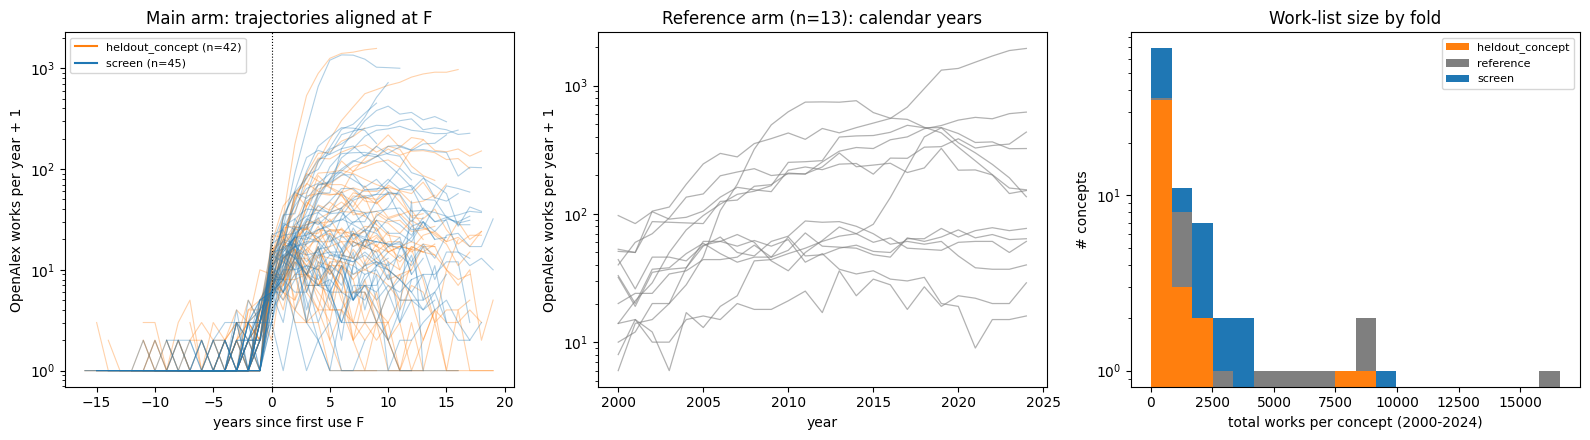

In [14]:
part_files = sorted((ROOT / "full_data_out").glob("full_data_out_*.json")) or [ROOT / "full_data_out.json"]
for p in part_files:
    print(f"{p}: {p.stat().st_size / 1e3:.1f} kB")
rows = []
for p in part_files:
    for d in orjson.loads(p.read_bytes())["datasets"]:
        if d["dataset"] != "concept_pool_2005_2016":
            continue
        for e in d["examples"]:
            i, o = json.loads(e["input"]), json.loads(e["output"])
            rows.append({"phrase": i["phrase"], "fold": e["metadata_fold"], "route": e["metadata_retrieval_route"],
                         "F": i.get("F"), "V": i.get("early_volume_V"), "origin_field": (i.get("origin_field") or {}).get("name"),
                         "n_works": o["n_works"], "counts": {int(y): c for y, c in o["oa_counts_by_year"].items()},
                         "flags": ",".join(e.get("metadata_flags") or [])})
df = pd.DataFrame(rows)
print(f"\n{len(df)} concepts exported")
print(pd.crosstab(df["fold"], df["route"], margins=True), "\n")
with pd.option_context("display.width", 200, "display.max_colwidth", 40):
    print(df.drop(columns="counts").sort_values("n_works", ascending=False).head(15).to_string(index=False))

colors = {"screen": "tab:blue", "heldout_concept": "tab:orange", "reference": "tab:gray"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
main_arm, ref_arm = df[df["F"].notna()], df[df["F"].isna()]  # reference concepts have no first-use year F
ax = axes[0]
for fold, g in main_arm.groupby("fold"):
    for _, r in g.iterrows():
        ys = sorted(r["counts"])
        ax.plot([y - r["F"] for y in ys], [r["counts"][y] + 1 for y in ys], color=colors.get(fold, "k"), alpha=0.35, lw=0.8)
    ax.plot([], [], color=colors.get(fold, "k"), label=f"{fold} (n={len(g)})")
ax.set_yscale("log"); ax.axvline(0, color="k", ls=":", lw=0.8)
ax.set_xlabel("years since first use F"); ax.set_ylabel("OpenAlex works per year + 1")
ax.set_title("Main arm: trajectories aligned at F"); ax.legend(fontsize=8)
ax = axes[1]
for _, r in ref_arm.iterrows():
    ys = sorted(r["counts"])
    ax.plot(ys, [r["counts"][y] + 1 for y in ys], color=colors["reference"], alpha=0.6, lw=0.9)
ax.set_yscale("log"); ax.set_xlabel("year"); ax.set_ylabel("OpenAlex works per year + 1")
ax.set_title(f"Reference arm (n={len(ref_arm)}): calendar years")
ax = axes[2]
ax.hist([g["n_works"] for _, g in df.groupby("fold")], bins=20, label=[f for f, _ in df.groupby("fold")],
        color=[colors.get(f, "k") for f, _ in df.groupby("fold")], stacked=True, log=True)
ax.set_xlabel("total works per concept (2000-2024)"); ax.set_ylabel("# concepts"); ax.set_title("Work-list size by fold"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()